C:\Users\anura\AppData\Local\Temp\ipykernel_24284\1204834272.py:5: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("NYPD_Complaint_Data_Current_YTD_cleaned.csv")


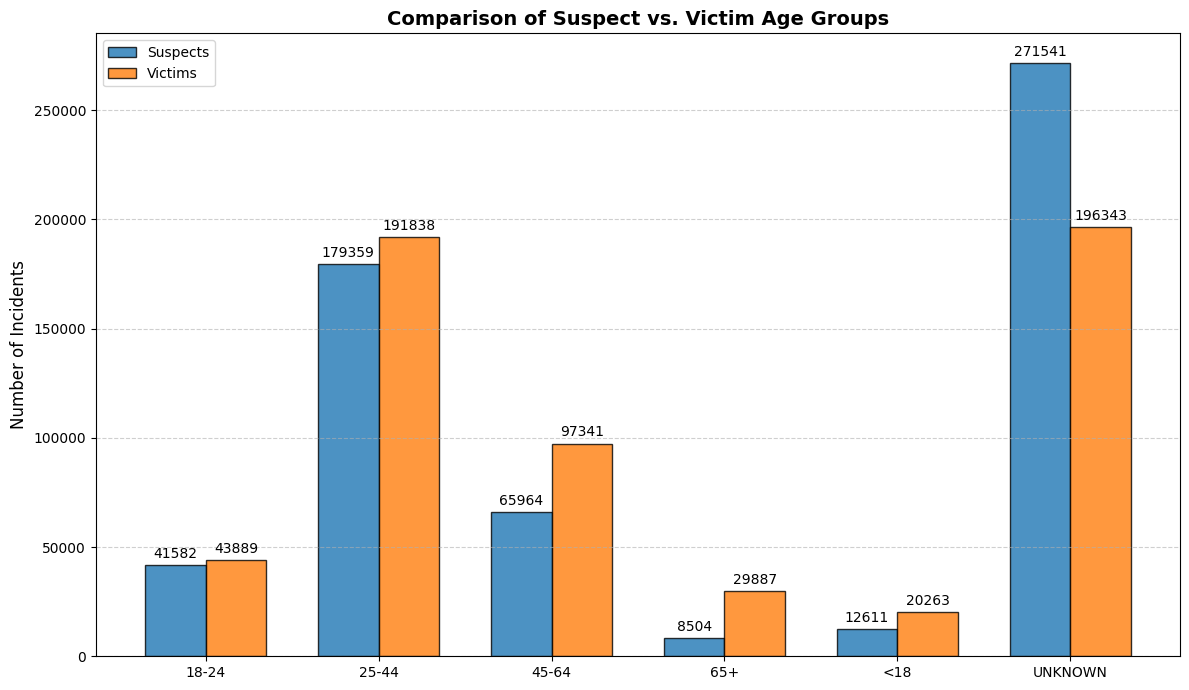

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("NYPD_Complaint_Data_Current_YTD_cleaned.csv")

# 1. Count the occurrences for each age group
susp_counts = df['SUSP_AGE_GROUP_CLEAN'].value_counts()
vic_counts = df['VIC_AGE_GROUP_CLEAN'].value_counts()

# 2. Create a unified list of all age groups present in the data
all_groups = sorted(list(set(susp_counts.index) | set(vic_counts.index)))

# 3. Align the counts to this unified list (filling missing groups with 0)
susp_plot = susp_counts.reindex(all_groups, fill_value=0)
vic_plot = vic_counts.reindex(all_groups, fill_value=0)

# 4. Plotting
x = np.arange(len(all_groups))  # label locations
width = 0.35                    # width of the bars

fig, ax = plt.subplots(figsize=(12, 7))
rects1 = ax.bar(x - width/2, susp_plot, width, label='Suspects', color='#1f77b4', alpha=0.8, edgecolor='black')
rects2 = ax.bar(x + width/2, vic_plot, width, label='Victims', color='#ff7f0e', alpha=0.8, edgecolor='black')

# Add text for labels, title and custom x-axis tick labels
ax.set_ylabel('Number of Incidents', fontsize=12)
ax.set_title('Comparison of Suspect vs. Victim Age Groups', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(all_groups)
ax.legend()

# Add value labels on top of each bar
ax.bar_label(rects1, padding=3)
ax.bar_label(rects2, padding=3)

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()